This is the 3rd file to run after the second file and after the cv, models and preprocessing parts are coded
We can JSUT RUN THIS FILE FIRST

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root added to path:", project_root)

Project root added to path: C:\Users\saw\Documents\fyp


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
# from sklearn.metrics import mean_squared_error

# Project imports
from src.preprocessing import get_preprocessor
from src.crossvalidation import get_cv
from src.models import get_ridge_pipeline

In [3]:
DATA_PATH = Path("../data/raw/2017-2018 TrainSet.xlsx")
df = pd.read_excel(DATA_PATH)

def assign_perf_group(gpa):
    if gpa <= 2.99:
        return "Underperforming"
    elif gpa <= 3.29:
        return "Average"
    else:
        return "Performing"

df["GroupLabel"] = df["FinalGPA"].apply(assign_perf_group)


In [4]:
numeric_features = [
    'Zscore', 'EnglishMarks'
]
numeric_features_sem1 = [
    'Zscore','EnglishMarks','S1',
]
numeric_features_sem2 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2',
]
numeric_features_sem3 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2', 'S3',
]
numeric_features_sem4 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2', 'S3', 'S4',
]
numeric_features_sem5 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2', 'S3', 'S4', 'S5'
]
numeric_features_sem6 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6',
]
numeric_features_sem7 = [
    'Zscore', 'EnglishMarks', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7',
]
numeric_features_sem8 = [
    'Zscore', 'EnglishMarks',
    'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8'
]
categorical_features = [
    'Gender', 'Department', 'District', 'MediumAL'
]

X = df[numeric_features + categorical_features]
y = df["FinalGPA"]
strata = df["GroupLabel"]

Model for PreAcademic Factors

In [5]:
preprocessor = get_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features
)

ridge_model = get_ridge_pipeline(
    preprocessor=preprocessor,
    alpha=1.0  # fixed baseline
)

Note on what mask is doing for each g
so what happens from mask is we check if in a fold ,there is atleast one value for group g and if it has only we will calculate the rmse for that g in that fold and in that way we get the rmse for each g in each fold for the list g

In [6]:
import sklearn
import sklearn.metrics
import numpy as np  
cv = get_cv()

rmse_scores = []
r2_scores = []

groups = df["GroupLabel"].unique()
group_rmse = {g: [] for g in groups}
group_r2 = {g: [] for g in groups}
group_bias = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx] #for example row 1 and 3 selected for val and other rows for train and others for test kinda thing here
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model.fit(X_train, y_train)
    
    y_pred = ridge_model.predict(X_val)
    
    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred)
    r2 = sklearn.metrics.r2_score(y_val, y_pred)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred[mask]
                
                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation
                
                group_rmse[g].append(rmse_g)
                group_r2[g].append(r2_g)
                group_bias[g].append(bias_g)

  
    

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

In [7]:
print(rmse_scores)

[0.23095596296146712, 0.3895111324963384, 0.2992262472857227, 0.35829082283014096, 0.41805091281029444, 0.3900442363286998, 0.34487183436141927, 0.3560013067306392, 0.32740084437500744, 0.2817186081065024, 0.3095391879276655, 0.48945661862335416, 0.3022431897398595, 0.33325854310255865, 0.31988455040235747, 0.3780788374841298, 0.374799489929033, 0.36833683930006267, 0.35168677575558227, 0.34554701498054874, 0.30980668745116313, 0.29261634496739114, 0.30365808714445225, 0.40008625608460346, 0.4041698753651627, 0.3630599748802968, 0.3306014552473653, 0.31954101683891245, 0.3821431498512206, 0.38054739930930964, 0.34420914964799504, 0.40139444364247884, 0.2824317910588623, 0.38792974400053415, 0.3505516744308801, 0.2823231186222837, 0.34799720164531167, 0.3566740489075344, 0.3819751279697646, 0.39401526482301563, 0.3589414811230129, 0.3915952169992176, 0.3805579244831608, 0.2591578797054346, 0.3156392399425241, 0.2643269339686172, 0.3337609686089905, 0.35913796637869366, 0.429974133337060

In [8]:
rmse_scores = np.array(rmse_scores)

print("Mean RMSE:", f"{rmse_scores.mean():.3f}")
print("SD RMSE:", f"{rmse_scores.std():.3f}")
print("Mean R2:", f"{np.mean(r2_scores):.3f}")
print("SD R2:", f"{np.std(r2_scores):.3f}")

Mean RMSE: 0.348
SD RMSE: 0.048
Mean R2: 0.385
SD R2: 0.204


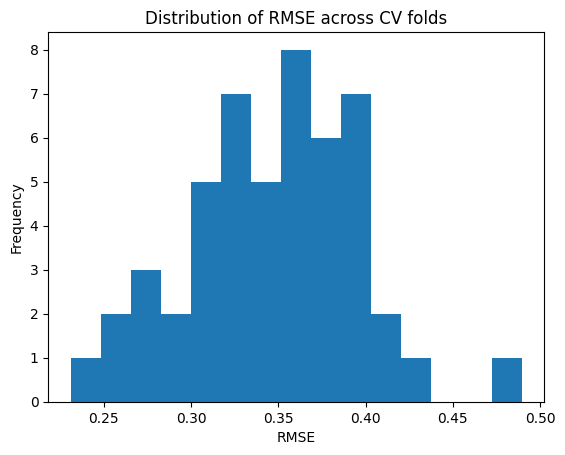

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(rmse_scores, bins=15)
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.title("Distribution of RMSE across CV folds")
plt.show()

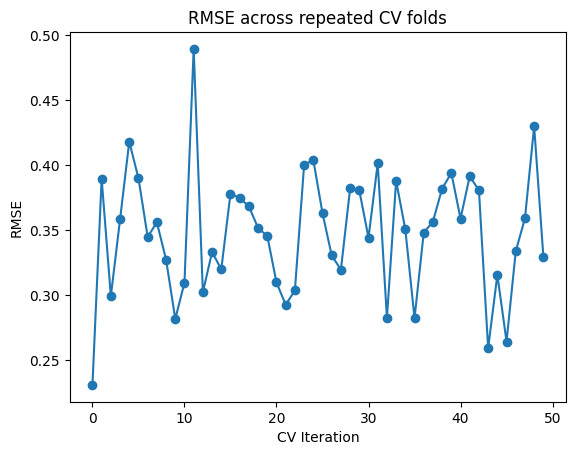

In [10]:
plt.figure()
plt.plot(rmse_scores, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds")
plt.show()

Group-wise RMSE

In [11]:
for g in group_rmse:
    vals = np.array(group_rmse[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2[g]).mean():.3f}, SD = {np.array(group_r2[g]).std():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias[g]).mean():.3f}, SD = {np.array(group_bias[g]).std():.3f}")

    # do i need sd of r2 and bias? maybe not as much as rmse but it could be interesting to see if some groups have more variability in bias or r2 than others which could indicate less stable performance for those groups.

Performing: Mean RMSE = 0.299, SD = 0.051
Performing: Mean R2 = -1.540, SD = 0.991
Performing: Mean Bias = 0.182, SD = 0.060
Underperforming: Mean RMSE = 0.498, SD = 0.117
Underperforming: Mean R2 = -2.798, SD = 2.715
Underperforming: Mean Bias = -0.343, SD = 0.095
Average: Mean RMSE = 0.191, SD = 0.055
Average: Mean R2 = -4.892, SD = 3.963
Average: Mean Bias = -0.007, SD = 0.068


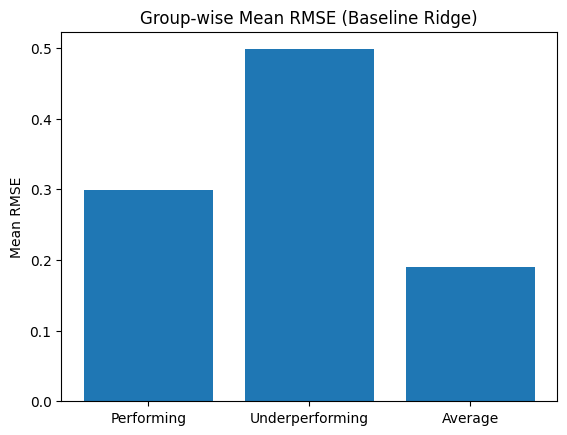

In [12]:
means = [np.mean(group_rmse[g]) for g in groups]

plt.figure()
plt.bar(groups, means)
plt.ylabel("Mean RMSE")
plt.title("Group-wise Mean RMSE (Baseline Ridge)")
plt.show()

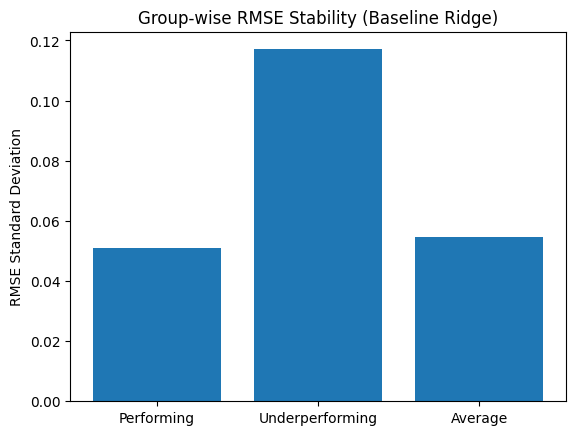

In [13]:
stds = [np.std(group_rmse[g]) for g in groups]

plt.figure()
plt.bar(groups, stds)
plt.ylabel("RMSE Standard Deviation")
plt.title("Group-wise RMSE Stability (Baseline Ridge)")
plt.show()


In [14]:
results = {}
results["S0"] = {
    "rmse": rmse_scores,
    "r2": r2_scores,
    "group_rmse": group_rmse,
    "group_r2": group_r2,
    "group_bias": group_bias
}

The pre-academic baseline model demonstrated moderate predictive capability, explaining 34.5% of the variance in final GPA with an average RMSE of 0.373. While overall performance remained relatively stable across folds, subgroup analysis revealed substantial heterogeneity. High-performing students were systematically underpredicted, while underperforming students were overpredicted, indicating regression-to-the-mean behavior. These findings establish a baseline and motivate the incorporation of semester-level academic trajectories for improved early prediction reliability.

SEMESTER 1 MODEL

In [16]:
preprocessor_s1 = get_preprocessor(
    numeric_features=numeric_features_sem1,
    categorical_features=categorical_features
)

ridge_model_s1 = get_ridge_pipeline(
    preprocessor=preprocessor_s1,
    alpha=1.0  # fixed baseline
)

X = df[numeric_features_sem1 + categorical_features]

In [17]:
rmse_scores_s1 = []
r2_scores_s1 = []

groups = df["GroupLabel"].unique()
group_rmse_s1 = {g: [] for g in groups}
group_r2_s1 = {g: [] for g in groups}
group_bias_s1 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s1.fit(X_train, y_train)

    y_pred_s1 = ridge_model_s1.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s1)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s1)
    rmse_scores_s1.append(rmse)
    r2_scores_s1.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s1[mask]
                # this should be updated
                
                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation
                
                group_rmse_s1[g].append(rmse_g) #variable name should be updated
                group_r2_s1[g].append(r2_g)
                group_bias_s1[g].append(bias_g)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

In [18]:
# print(rmse_scores_s1)

rmse_scores_s1 = np.array(rmse_scores_s1)
print("Mean RMSE SEM1:", f"{rmse_scores_s1.mean():.3f}")
print("SD RMSE SEM1:", f"{rmse_scores_s1.std():.3f}")
print("Mean R2 SEM1:", f"{np.mean(r2_scores_s1):.3f}")
print("SD R2 SEM1:", f"{np.std(r2_scores_s1):.3f}")

Mean RMSE SEM1: 0.255
SD RMSE SEM1: 0.037
Mean R2 SEM1: 0.674
SD R2 SEM1: 0.088


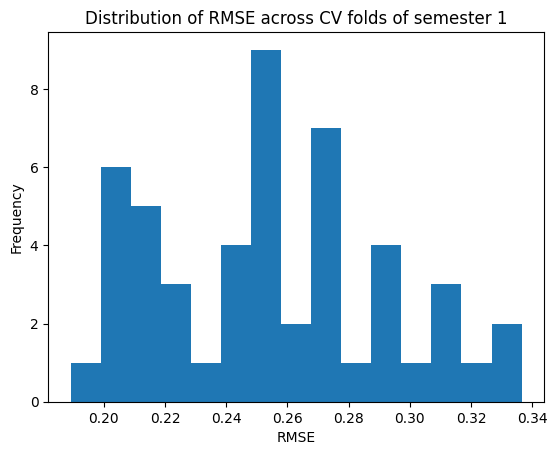

In [19]:
plt.figure()
plt.hist(rmse_scores_s1, bins=15)
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.title("Distribution of RMSE across CV folds of semester 1")
plt.show()

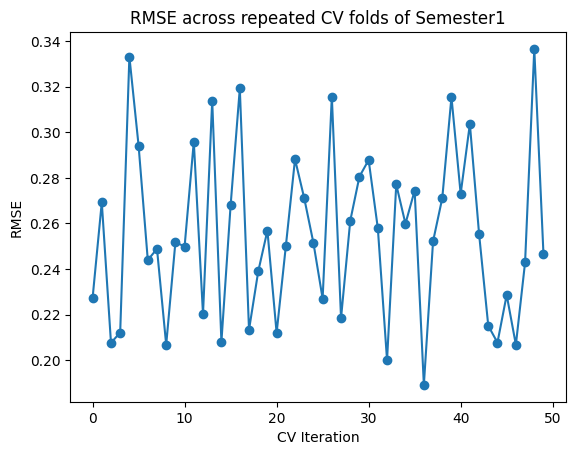

In [20]:
plt.figure()
plt.plot(rmse_scores_s1, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester1")
plt.show()

In [21]:
for g in group_rmse_s1:
    vals = np.array(group_rmse_s1[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s1[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s1[g]).mean():.3f}")

Performing: Mean RMSE = 0.206, SD = 0.033
Performing: Mean R2 = -0.222
Performing: Mean Bias = 0.078
Underperforming: Mean RMSE = 0.354, SD = 0.100
Underperforming: Mean R2 = -0.797
Underperforming: Mean Bias = -0.167
Average: Mean RMSE = 0.195, SD = 0.042
Average: Mean R2 = -5.043
Average: Mean Bias = 0.022


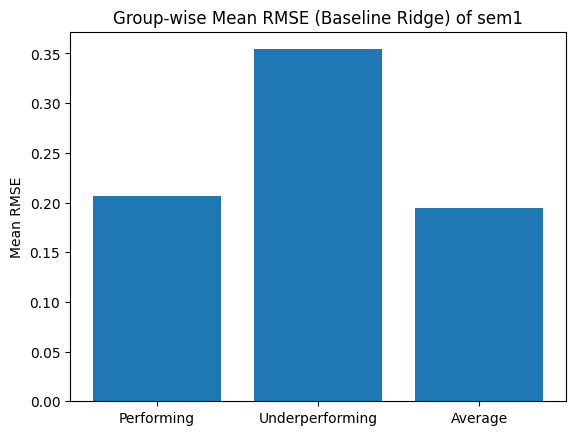

In [22]:
means = [np.mean(group_rmse_s1[g]) for g in groups]

plt.figure()
plt.bar(groups, means)
plt.ylabel("Mean RMSE")
plt.title("Group-wise Mean RMSE (Baseline Ridge) of sem1")
plt.show()

Prediction accuracy improves considerably after Semester 1, with mean RMSE decreasing from 0.37 to 0.28 and variability across cross-validation folds also reducing.
However, subgroup analysis shows that prediction errors remain substantially higher for underperforming students, and their prediction stability is lower compared to other groups.
This suggests that while Semester 1 provides a stronger signal for final GPA prediction, it may still be too early for reliably identifying students at risk of low final performance.
Prediction error for high-performing students decreases substantially after Semester 1, suggesting that strong early academic performance provides a clearer signal of final GPA.
Average-performing students continue to have the lowest prediction error, suggesting regression toward the mean behaviour of the model.


In [23]:
results["S1"] = {
    "rmse": rmse_scores_s1,
    "r2": r2_scores_s1,
    "group_rmse": group_rmse_s1,
    "group_r2": group_r2_s1,
    "group_bias": group_bias_s1
}
# print(results)

SEMESTER 2

In [24]:
preprocessor_s2 = get_preprocessor(
    numeric_features=numeric_features_sem2,
    categorical_features=categorical_features
)

ridge_model_s2 = get_ridge_pipeline(
    preprocessor=preprocessor_s2,
    alpha=1.0  # fixed baseline
)

X = df[numeric_features_sem2 + categorical_features]

In [25]:
rmse_scores_s2 = []
r2_scores_s2 = []

groups = df["GroupLabel"].unique()
group_rmse_s2 = {g: [] for g in groups}
group_r2_s2 = {g: [] for g in groups}
group_bias_s2 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s2.fit(X_train, y_train)

    y_pred_s2 = ridge_model_s2.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s2)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s2)
    rmse_scores_s2.append(rmse)
    r2_scores_s2.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s2[mask]
                
                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation
                
                group_rmse_s2[g].append(rmse_g)
                group_r2_s2[g].append(r2_g)
                group_bias_s2[g].append(bias_g)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

In [26]:
rmse_scores_s2 = np.array(rmse_scores_s2)

print("Mean RMSE SEM2:", f"{rmse_scores_s2.mean():.3f}")
print("SD of RMSE SEM2:", f"{rmse_scores_s2.std():.3f}")
print("Mean R2 SEM2:", f"{np.mean(r2_scores_s2):.3f}")
print("SD R2 SEM2:", f"{np.std(r2_scores_s2):.3f}")


Mean RMSE SEM2: 0.205
SD of RMSE SEM2: 0.027
Mean R2 SEM2: 0.786
SD R2 SEM2: 0.073


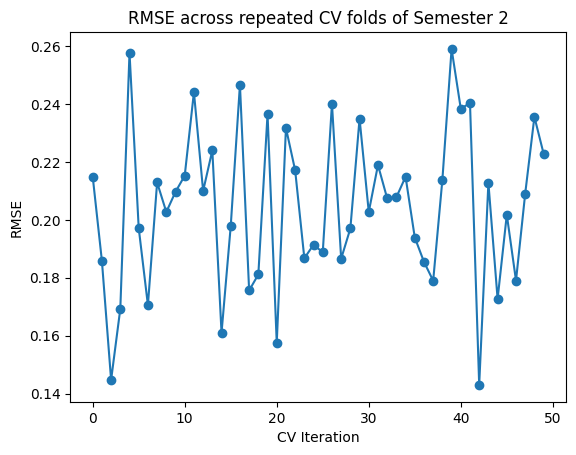

In [27]:
plt.figure()
plt.plot(rmse_scores_s2, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester 2")
plt.show()

In [28]:
for g in group_rmse_s2:
    vals = np.array(group_rmse_s2[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s2[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s2[g]).mean():.3f}")

Performing: Mean RMSE = 0.159, SD = 0.028
Performing: Mean R2 = 0.258
Performing: Mean Bias = 0.042
Underperforming: Mean RMSE = 0.291, SD = 0.067
Underperforming: Mean R2 = -0.429
Underperforming: Mean Bias = -0.097
Average: Mean RMSE = 0.162, SD = 0.030
Average: Mean R2 = -3.162
Average: Mean Bias = 0.016


Prediction accuracy improves substantially after Semester 1 and continues to improve slightly after Semester 2, but the rate of improvement decreases, suggesting diminishing returns as more semesters are added. The variability of RMSE across repeated CV folds remains low and comparable to Semester 1, indicating that model stability does not change significantly after Semester 1. The model continues to have the highest prediction error for underperforming students even after Semester 2, indicating that low final GPA remains difficult to predict early in the program. Prediction accuracy for high-performing students improves steadily across semesters, suggesting that strong academic performance produces a consistent signal for final GPA prediction.

The slight increase in SD at Semester 2 is small and does not indicate instability, as the variation remains within a narrow range compared to Semester 0.

ompared to Semester 1, the Semester 2 model shows a similar spread of RMSE values across cross-validation folds, indicating that prediction stability remains consistent after the first semester, with no evidence of increased variability.

In [29]:
results["S2"] = {
    "rmse": rmse_scores_s2,
    "r2": r2_scores_s2,
    "group_rmse": group_rmse_s2,
    "group_r2": group_r2_s2,
    "group_bias": group_bias_s2
}

SEMESTER 3

In [30]:
preprocessor_s3 = get_preprocessor(
    numeric_features=numeric_features_sem3,
    categorical_features=categorical_features
)

ridge_model_s3 = get_ridge_pipeline(
    preprocessor=preprocessor_s3,
    alpha=1.0  # fixed baseline
)

X = df[numeric_features_sem3 + categorical_features]

In [31]:
rmse_scores_s3 = []
r2_scores_s3 = []

groups = df["GroupLabel"].unique()
group_rmse_s3 = {g: [] for g in groups}
group_r2_s3 = {g: [] for g in groups}
group_bias_s3 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s3.fit(X_train, y_train)

    y_pred_s3 = ridge_model_s3.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s3)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s3)
    rmse_scores_s3.append(rmse)
    r2_scores_s3.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s3[mask]

                rmse_g_s3 = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g_s3 = sklearn.metrics.r2_score(actual, pred)
                bias_g_s3 = np.mean(actual - pred) # Negative = Overestimation

                group_rmse_s3[g].append(rmse_g_s3)
                group_r2_s3[g].append(r2_g_s3)
                group_bias_s3[g].append(bias_g_s3)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

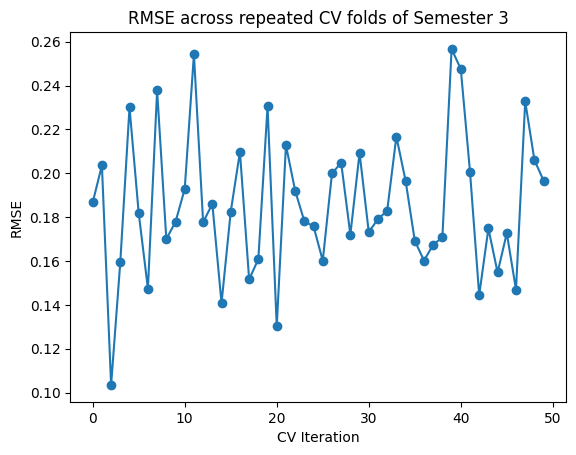

In [32]:
plt.figure()
plt.plot(rmse_scores_s3, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester 3")
plt.show()

In [33]:
rmse_scores_s3 = np.array(rmse_scores_s3)

print('Mean RMSE of SEM3:', f"{rmse_scores_s3.mean():.3f}")
print('SD of RMSE Sem3:', f"{rmse_scores_s3.std():.3f}")
print("Mean R2 SEM3:", f"{np.mean(r2_scores_s3):.3f}")
print("SD R2 SEM3:", f"{np.std(r2_scores_s3):.3f}")

Mean RMSE of SEM3: 0.185
SD of RMSE Sem3: 0.032
Mean R2 SEM3: 0.823
SD R2 SEM3: 0.070


In [34]:
for g in group_rmse_s3:
    vals = np.array(group_rmse_s3[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s3[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s3[g]).mean():.3f}")

Performing: Mean RMSE = 0.138, SD = 0.024
Performing: Mean R2 = 0.449
Performing: Mean Bias = 0.028
Underperforming: Mean RMSE = 0.274, SD = 0.081
Underperforming: Mean R2 = -0.249
Underperforming: Mean Bias = -0.080
Average: Mean RMSE = 0.135, SD = 0.030
Average: Mean R2 = -1.851
Average: Mean Bias = 0.025


In [35]:
results["S3"] = {
    "rmse": rmse_scores_s3,
    "r2": r2_scores_s3,
    "group_rmse": group_rmse_s3,
    "group_r2": group_r2_s3,
    "group_bias": group_bias_s3
}

Prediction accuracy improves steadily across semesters, with a substantial reduction in RMSE at Semester 3, suggesting that by the third semester the model has access to sufficient academic information to estimate final GPA with much higher precision. The Semester 3 model shows the narrowest spread of RMSE values across folds so far, indicating improved stability compared to earlier semesters. The standard deviation of RMSE reaches its lowest value at Semester 3, indicating that model performance is not only more accurate but also more consistent across cross-validation folds. Although prediction accuracy improves for all groups, underperforming students still have the highest prediction error, indicating that identifying low final GPA remains more difficult than predicting average or high performance. The results suggest that prediction accuracy improves gradually across semesters, but a clear increase in both accuracy and stability occurs by Semester 3, indicating that this may be the earliest point at which final GPA can be predicted reliably.

SEMESTER 4

In [36]:
preprocessor_s4 = get_preprocessor(
    numeric_features=numeric_features_sem4,
    categorical_features=categorical_features
)

ridge_model_s4 = get_ridge_pipeline(
    preprocessor=preprocessor_s4,
    alpha=1.0  # fixed baseline
)

X = df[numeric_features_sem4 + categorical_features]

In [37]:
rmse_scores_s4 = []
r2_scores_s4 = []

groups = df["GroupLabel"].unique()
group_rmse_s4 = {g: [] for g in groups}
group_r2_s4 = {g: [] for g in groups}
group_bias_s4 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s4.fit(X_train, y_train)

    y_pred_s4 = ridge_model_s4.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s4)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s4)
    rmse_scores_s4.append(rmse)
    r2_scores_s4.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s4[mask]

                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation
                
                group_rmse_s4[g].append(rmse_g)
                group_r2_s4[g].append(r2_g)
                group_bias_s4[g].append(bias_g)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

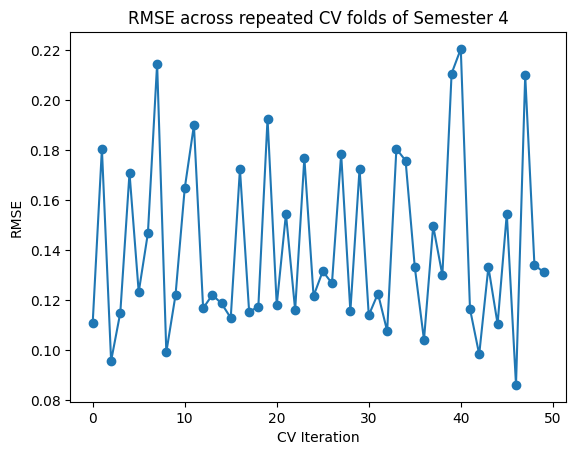

In [38]:
plt.figure()
plt.plot(rmse_scores_s4, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester 4")
plt.show()

In [39]:
rmse_scores_s4 = np.array(rmse_scores_s4)

print("Mean RMSE of sem 4:", f"{rmse_scores_s4.mean():.3f}")
print("SD of RMSE of sem 4:", f"{rmse_scores_s4.std():.3f}")
print("Mean R2 of sem 4:", f"{np.mean(r2_scores_s4):.3f}")
print("SD R2 of sem 4:", f"{np.std(r2_scores_s4):.3f}")

Mean RMSE of sem 4: 0.141
SD of RMSE of sem 4: 0.035
Mean R2 of sem 4: 0.896
SD R2 of sem 4: 0.053


In [40]:
for g in group_rmse_s4:
    vals = np.array(group_rmse_s4[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s4[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s4[g]).mean():.3f}")

Performing: Mean RMSE = 0.097, SD = 0.019
Performing: Mean R2 = 0.723
Performing: Mean Bias = 0.019
Underperforming: Mean RMSE = 0.208, SD = 0.084
Underperforming: Mean R2 = 0.250
Underperforming: Mean Bias = -0.052
Average: Mean RMSE = 0.109, SD = 0.032
Average: Mean R2 = -1.037
Average: Mean Bias = 0.012


In [41]:
results["S4"] = {
    "rmse": rmse_scores_s4,
    "r2": r2_scores_s4,
    "group_rmse": group_rmse_s4,
    "group_r2": group_r2_s4,
    "group_bias": group_bias_s4
}

SEMESTER 5

In [42]:
preprocessor_s5 = get_preprocessor(
    numeric_features=numeric_features_sem5,
    categorical_features=categorical_features
)

ridge_model_s5 = get_ridge_pipeline(
    preprocessor=preprocessor_s5,
    alpha=1.0
)

X=df[numeric_features_sem5 + categorical_features]

In [43]:
rmse_scores_s5 = []
r2_scores_s5 = []

groups = df["GroupLabel"].unique()
group_rmse_s5 = {g: [] for g in groups}
group_r2_s5 = {g: [] for g in groups}
group_bias_s5 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s5.fit(X_train, y_train)

    y_pred_s5 = ridge_model_s5.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s5)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s5)
    rmse_scores_s5.append(rmse)
    r2_scores_s5.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s5[mask]

                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation

                group_rmse_s5[g].append(rmse_g)
                group_r2_s5[g].append(r2_g)
                group_bias_s5[g].append(bias_g)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

In [44]:
rmse_scores_s5 = np.array(rmse_scores_s5)

print("Mean RMSE of Semester 5:", f"{rmse_scores_s5.mean():.3f}")
print("SD of RMSE of Semester 5:", f"{rmse_scores_s5.std():.3f}")
print("Mean R2 of Semester 5:", f"{np.mean(r2_scores_s5):.3f}")
print("SD R2 of Semester 5:", f"{np.std(r2_scores_s5):.3f}")

Mean RMSE of Semester 5: 0.116
SD of RMSE of Semester 5: 0.033
Mean R2 of Semester 5: 0.931
SD R2 of Semester 5: 0.035


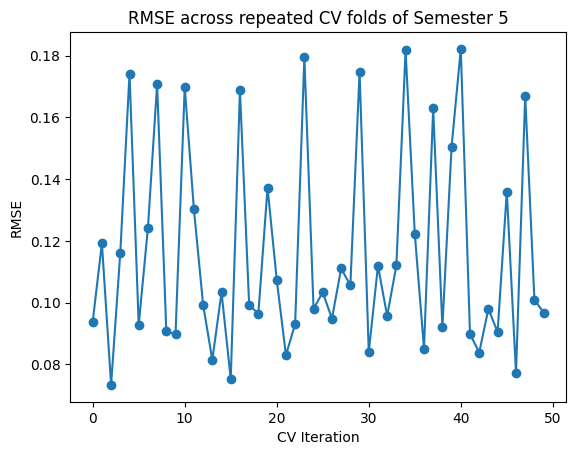

In [45]:
plt.figure()
plt.plot(rmse_scores_s5, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester 5")
plt.show()

In [46]:
for g in group_rmse_s5:
    vals = np.array(group_rmse_s5[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s5[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s5[g]).mean():.3f}")

Performing: Mean RMSE = 0.079, SD = 0.020
Performing: Mean R2 = 0.810
Performing: Mean Bias = 0.010
Underperforming: Mean RMSE = 0.167, SD = 0.080
Underperforming: Mean R2 = 0.570
Underperforming: Mean Bias = -0.035
Average: Mean RMSE = 0.092, SD = 0.023
Average: Mean R2 = -0.389
Average: Mean Bias = 0.017


SEMESTER 6 - to check for underperforming students

In [47]:
preprocessor_s6 = get_preprocessor(
    numeric_features=numeric_features_sem6,
    categorical_features=categorical_features
)

ridge_model_s6= get_ridge_pipeline(
    preprocessor=preprocessor_s6,
    alpha=1.0
)

X=df[numeric_features_sem6+categorical_features]

In [48]:
rmse_scores_s6 = []
r2_scores_s6 = []

groups = df["GroupLabel"].unique()
group_rmse_s6 = {g: [] for g in groups}
group_r2_s6 = {g: [] for g in groups}
group_bias_s6 = {g: [] for g in groups}

for train_idx, val_idx in cv.split(X, strata):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    g_val = strata.iloc[val_idx]

    ridge_model_s6.fit(X_train, y_train)

    y_pred_s6 = ridge_model_s6.predict(X_val)

    rmse = sklearn.metrics.root_mean_squared_error(y_val, y_pred_s6)
    r2 = sklearn.metrics.r2_score(y_val, y_pred_s6)
    rmse_scores_s6.append(rmse)
    r2_scores_s6.append(r2)

    for g in groups:
            mask = g_val == g
            if mask.sum() > 0:
                actual = y_val[mask]
                pred = y_pred_s6[mask]

                rmse_g = sklearn.metrics.root_mean_squared_error(actual, pred)
                r2_g = sklearn.metrics.r2_score(actual, pred)
                bias_g = np.mean(actual - pred) # Negative = Overestimation

                group_rmse_s6[g].append(rmse_g)
                group_r2_s6[g].append(r2_g)
                group_bias_s6[g].append(bias_g)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, U

In [49]:
rmse_scores_s6=np.array(rmse_scores_s6)

print('Mean RMSE of Sem6:', f'{rmse_scores_s6.mean():.3f}')
print('SD of RMSE of sem6:', f'{rmse_scores_s6.std():.3f}')
print("Mean R2 of Semester 6:", f"{np.mean(r2_scores_s6):.3f}")
print("SD R2 of Semester 6:", f"{np.std(r2_scores_s6):.3f}")

Mean RMSE of Sem6: 0.097
SD of RMSE of sem6: 0.028
Mean R2 of Semester 6: 0.952
SD R2 of Semester 6: 0.023


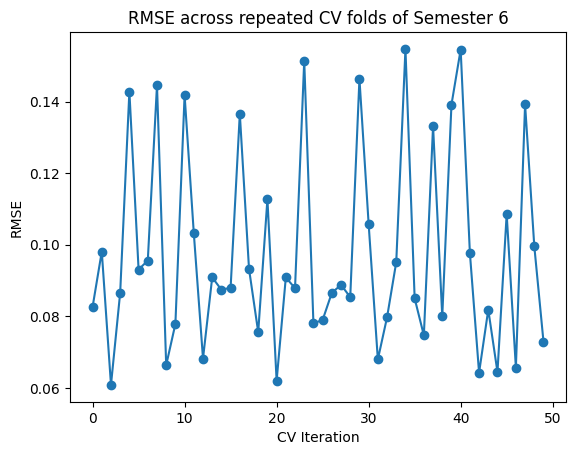

In [50]:
plt.figure()
plt.plot(rmse_scores_s6, marker='o')
plt.xlabel("CV Iteration")
plt.ylabel("RMSE")
plt.title("RMSE across repeated CV folds of Semester 6")
plt.show()

In [51]:
for g in group_rmse_s6:
    vals = np.array(group_rmse_s6[g])
    print(f"{g}: Mean RMSE = {vals.mean():.3f}, SD = {vals.std():.3f}")
    print(f"{g}: Mean R2 = {np.array(group_r2_s6[g]).mean():.3f}") 
    print(f"{g}: Mean Bias = {np.array(group_bias_s6[g]).mean():.3f}")

Performing: Mean RMSE = 0.058, SD = 0.010
Performing: Mean R2 = 0.901
Performing: Mean Bias = 0.009
Underperforming: Mean RMSE = 0.154, SD = 0.065
Underperforming: Mean R2 = 0.673
Underperforming: Mean Bias = -0.013
Average: Mean RMSE = 0.068, SD = 0.021
Average: Mean R2 = 0.226
Average: Mean Bias = 0.005


The earliest semester at which final GPA can be predicted reliably differs across performance groups.
High-performing students can be predicted with reasonable accuracy as early as Semester 2–3, while average students require approximately three semesters of academic data.
In contrast, underperforming students require substantially more history, with reliable predictions emerging only after Semester 5–6.
Overall, prediction accuracy improves rapidly in early semesters and stabilizes after Semester 3–4, indicating that mid-program performance provides sufficient information for reliable final GPA prediction, although identifying low-performing students remains more challenging.

In [52]:
results["S6"] = {
    "rmse": rmse_scores_s6,
    "group_rmse": group_rmse_s6,
    "group_r2": group_r2_s6,
    "group_bias": group_bias_s6
}

TESTING THE MODELS

In [53]:
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

# Load test set
TEST_DATA_PATH = Path("../data/raw/2019 TestSet.xlsx")
test_df = pd.read_excel(TEST_DATA_PATH)

# Assign groups to test set
test_df["GroupLabel"] = test_df["FinalGPA"].apply(assign_perf_group)

def evaluate_on_test(
    train_df,
    test_df,
    numeric_features,
    categorical_features,
    alpha=1.0
):
    
    # Train data
    X_train = train_df[numeric_features + categorical_features]
    y_train = train_df["FinalGPA"]

    # Test data
    X_test = test_df[numeric_features + categorical_features]
    y_test = test_df["FinalGPA"]

    test_groups = test_df["GroupLabel"]

    # Build fresh preprocessor
    preprocessor = get_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features
    )

    # Final model
    ridge_model = get_ridge_pipeline(
        preprocessor=preprocessor,
        alpha=alpha
    )

    # Train on ALL historical data
    ridge_model.fit(X_train, y_train)

    # Predict on 2020 batch
    y_pred = ridge_model.predict(X_test)

    # Overall metrics
    overall_rmse = root_mean_squared_error(y_test, y_pred)
    overall_r2 = r2_score(y_test, y_pred)
    overall_bias = np.mean(y_test - y_pred)

    print("\n=== Overall Test Results ===")
    print(f"RMSE: {overall_rmse:.3f}")
    print(f"R2: {overall_r2:.3f}")
    print(f"Bias: {overall_bias:.3f}")

    # Groupwise metrics
    groups = test_groups.unique()

    print("\n=== Groupwise Test Results ===")

    for g in groups:
        mask = test_groups == g

        actual = y_test[mask]
        pred = y_pred[mask]

        rmse_g = root_mean_squared_error(actual, pred)
        r2_g = r2_score(actual, pred)
        bias_g = np.mean(actual - pred)

        print(f"\n{g}")
        print(f"RMSE: {rmse_g:.3f}")
        print(f"R2: {r2_g:.3f}")
        print(f"Bias: {bias_g:.3f}")

    return ridge_model, y_pred

In [54]:

#sem 0
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    alpha=1.0
)


=== Overall Test Results ===
RMSE: 0.437
R2: 0.172
Bias: -0.053

=== Groupwise Test Results ===

Underperforming
RMSE: 0.606
R2: -2.599
Bias: -0.358

Performing
RMSE: 0.332
R2: -1.528
Bias: 0.178

Average
RMSE: 0.424
R2: -28.277
Bias: -0.274


c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [55]:
#sem 1
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features_sem1,
    categorical_features=categorical_features,
    alpha=1.0
)


=== Overall Test Results ===
RMSE: 0.349
R2: 0.471
Bias: -0.117

=== Groupwise Test Results ===

Underperforming
RMSE: 0.540
R2: -1.858
Bias: -0.283

Performing
RMSE: 0.200
R2: 0.079
Bias: -0.002

Average
RMSE: 0.349
R2: -18.896
Bias: -0.209


c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [56]:
#sem 2
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features_sem2,
    categorical_features=categorical_features,
    alpha=1.0
)


=== Overall Test Results ===
RMSE: 0.382
R2: 0.365
Bias: -0.271

=== Groupwise Test Results ===

Underperforming
RMSE: 0.603
R2: -2.563
Bias: -0.480

Performing
RMSE: 0.208
R2: 0.010
Bias: -0.152

Average
RMSE: 0.378
R2: -22.327
Bias: -0.321


c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [57]:
#sem 3
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features_sem3,
    categorical_features=categorical_features,
    alpha=1.0
)


=== Overall Test Results ===
RMSE: 0.261
R2: 0.704
Bias: -0.155

=== Groupwise Test Results ===

Underperforming
RMSE: 0.426
R2: -0.777
Bias: -0.302

Performing
RMSE: 0.142
R2: 0.538
Bias: -0.087

Average
RMSE: 0.228
R2: -7.445
Bias: -0.149


c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [58]:
#sem 4
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features_sem4,
    categorical_features=categorical_features,
    alpha=1.0
)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== Overall Test Results ===
RMSE: 0.181
R2: 0.858
Bias: -0.076

=== Groupwise Test Results ===

Underperforming
RMSE: 0.305
R2: 0.091
Bias: -0.202

Performing
RMSE: 0.091
R2: 0.809
Bias: -0.017

Average
RMSE: 0.144
R2: -2.383
Bias: -0.072


In [59]:
#sem 6
model_pre, pred_pre = evaluate_on_test(
    train_df=df,
    test_df=test_df,
    numeric_features=numeric_features_sem6,
    categorical_features=categorical_features,
    alpha=1.0
)

c:\Users\saw\Documents\fyp\venv_fyp\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== Overall Test Results ===
RMSE: 0.107
R2: 0.950
Bias: 0.025

=== Groupwise Test Results ===

Underperforming
RMSE: 0.163
R2: 0.738
Bias: -0.035

Performing
RMSE: 0.072
R2: 0.880
Bias: 0.048

Average
RMSE: 0.094
R2: -0.444
Bias: 0.041


In [60]:
df[["S1","S2","S3","FinalGPA"]].corr()

# test_df[["S1","S2","S3","FinalGPA"]].corr()

,S1,S2,S3,FinalGPA
S1,1.000000,0.809551,0.828530,0.853204
S2,0.809551,1.000000,0.855843,0.875228
S3,0.828530,0.855843,1.000000,0.905624
FinalGPA,0.853204,0.875228,0.905624,1.000000


In [61]:
test_df[["S1","S2","S3","FinalGPA"]].corr()

,S1,S2,S3,FinalGPA
S1,1.000000,0.597536,0.771745,0.762638
S2,0.597536,1.000000,0.841084,0.775908
S3,0.771745,0.841084,1.000000,0.921969
FinalGPA,0.762638,0.775908,0.921969,1.000000
